# Разведочный анализ данных о прокатах в Сеуле

Имеем датасет с информацией об аренде велосипедов в г.Сеул за определенный период. Задача данного анализа состоит в том, чтобы изучить особенности поведения рынка в различные периоды времени/сезоны, выявить лишнюю информацию, и подготовить данные для обучения предсказательной модели(деревья решений).
  
Разрабатываемая модель поможет оптимизировать работу прокатов, спрогнознировать нагрузку, чтобы определить необходимое кол-во сотрудников(поддержка, кассиры, механики) в разное рабочее время.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy
import seaborn as sns

In [2]:
df = pd.read_csv("SeoulBikeData.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8760 entries, 0 to 8759
Data columns (total 14 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Date                      8760 non-null   object 
 1   Rented Bike Count         8760 non-null   int64  
 2   Hour                      8760 non-null   int64  
 3   Temperature(C)            8760 non-null   float64
 4   Humidity(%)               8760 non-null   int64  
 5   Wind speed (m/s)          8760 non-null   float64
 6   Visibility (10m)          8760 non-null   int64  
 7   Dew point temperature(C)  8760 non-null   float64
 8   Solar Radiation (MJ/m2)   8760 non-null   float64
 9   Rainfall(mm)              8760 non-null   float64
 10  Snowfall (cm)             8760 non-null   float64
 11  Seasons                   8760 non-null   object 
 12  Holiday                   8760 non-null   object 
 13  Functioning Day           8760 non-null   object 
dtypes: float

## Анализ столбцов и очистка данных

Видим большое кол-во различных столбцов. Рассмотрим, что имеем: 

    - Наш целевой столбец - Rented Bike Count(Кол-во арендованных за это время байков);
    - Date - Дата в формате dd.mm.yyyy(текст);
    - Hour - Час из расчета от 0 до 24, целочисленный;
    - Temperature(C) - Температура в градусах Цельсия в данный час;
    - Humidity(%) - Влажность воздуха;
    - Wind speed (m/s) - Скорость ветра;
    - Visibility (10m) - Видимость, однако в таблице не условная единица размером в десяток метров, как выяснилось, это высота установки прибора, 2000 здесь означает именно 2000 метров;
    - Dew point temperature(C) - Точка росы. Это та критическая температура, при которой воздух достигает 100% влажности (насыщения) и больше не может удерживать пар. Излишек выпадает в виде конденсата (росы, инея, тумана).
    - Solar Radiation (MJ/m2) - интенсивность солнечного излучения(MJ = мегаджоуль (единица энергии) / m² = на квадратный метр). Чем больше число, тем ярче солнце и жарче от него.
    - Rainfall(mm)/Snowfall (cm) - Кол-во осадков в виде дождя/снега. 
    - Seasons - время года(весна, осень, лето, зима)
    - Holiday - не путать, это государственные праздники, не суббота/воскресенье. 
    - Functioning day - рабочий/не рабочий день.
  
Решение об удалении определенных столбцов будут принято в конце(за некоторыми исключениями).

In [3]:
df.describe()

,Rented Bike Count,Hour,Temperature(C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm)
count,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000
mean,704.602055,11.500000,12.882922,58.226256,1.724909,1436.825799,4.073813,0.569111,0.148687,0.075068
std,644.997468,6.922582,11.944825,20.362413,1.036300,608.298712,13.060369,0.868746,1.128193,0.436746
min,0.000000,0.000000,-17.800000,0.000000,0.000000,27.000000,-30.600000,0.000000,0.000000,0.000000
25%,191.000000,5.750000,3.500000,42.000000,0.900000,940.000000,-4.700000,0.000000,0.000000,0.000000
50%,504.500000,11.500000,13.700000,57.000000,1.500000,1698.000000,5.100000,0.010000,0.000000,0.000000
75%,1065.250000,17.250000,22.500000,74.000000,2.300000,2000.000000,14.800000,0.930000,0.000000,0.000000
max,3556.000000,23.000000,39.400000,98.000000,7.400000,2000.000000,27.200000,3.520000,35.000000,8.800000


Убеждаемся, что в числовых данных у нас нет странных выбросов, аномальных значений на порогах. Теперь рассмотрим текстовые данные на предмет опечаток(например вместо Yes написано Yess).

In [4]:
df.describe(include='str')

TypeError: numpy string dtypes are not allowed, use 'str' or 'object' instead

Можно сделать вывод, что данные в контексте грубых опечаток корректны, и таковых не имеют. Мы видим что по датам у нас столько уникальных значений, сколько дней в году, такую же картину наблюдаем и по остальным признакам. 

#### Functioning Day

Теперь разберем параметр "Functioning Day".

In [ ]:
df[df['Functioning Day'] == 'No']['Rented Bike Count'].describe()

count    295.0
mean       0.0
std        0.0
min        0.0
25%        0.0
50%        0.0
75%        0.0
max        0.0
Name: Rented Bike Count, dtype: float64

Видим что эти строчки не функциональны и не имеют практического смысла, так как продаж в эти дни не было, а в дни когда были, очевидно что значение столбца будет Yes, одинаковое для всех. Очистим строки нерабочих дней и удалим лишний столбец.

In [ ]:
df = df[df['Functioning Day'] == 'Yes'] 
df = df.drop(columns='Functioning Day')


#### Holiday

Разберем столбец Holiday.  
Как ведет себя спрос в зависимости от того, праздничный день или нет? Влияет ли на это сезон?  

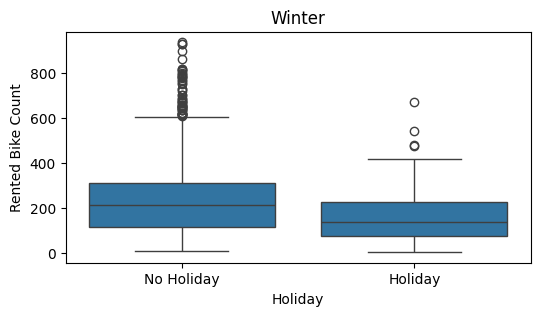

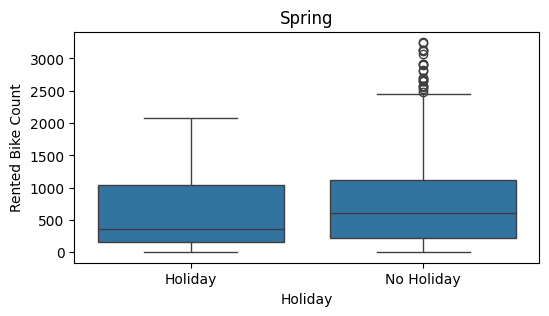

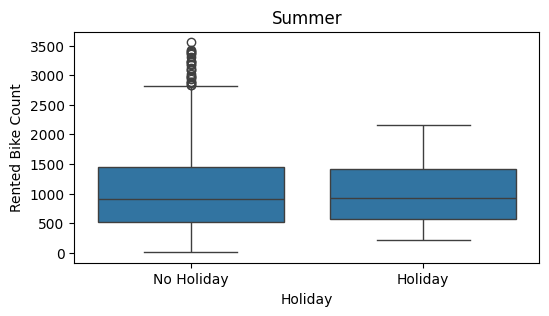

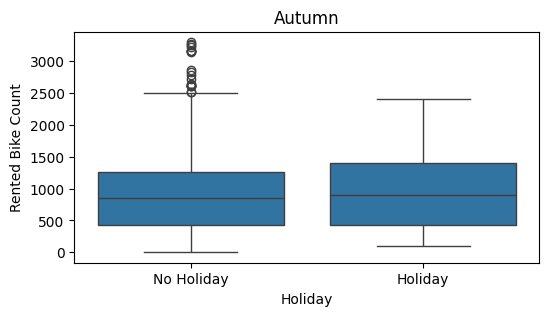

In [ ]:
for season in df['Seasons'].unique():
    plt.figure(figsize=(6, 3))
    sns.boxplot(data=df[df['Seasons'] == f'{season}'], x='Holiday', y='Rented Bike Count')
    plt.title(season)
    plt.show()

Исходя из полученных графиков делаем вывод:
1. Зимой в праздники нагрузка на прокат в среднем снижается;  
2. Весной медианное значение в праздники выше, более того, видим значительные выбросы в сторону большого кол-ва арендованных велосипедов. Открытые источники говорят, что причина не в особых праздниках. В это время в городе проходят фестивали цветения, люди стремятся на живописные маршруты, особенно вдоль реки Ханган.Цветение сакуры происходит каждый год примерно в одно и то же время, что и создает стабильную, повторяющуюся из года в год волну повышенного спроса в дни отдыха;  
3. Летом и осенью распределения очень схожи, можно сделать вывод что наличие праздника не играет значительной роли.

Не смотря на слабовыраженное влияние на данные, в некоторых сценариях использования деревьев решений признак может оказаться полезным, а не выполнять роль шума. Применим бинарное преобразование.

#### Числовые признаки

Оставим пока что столбец Seasons, так как он удобен для статистических расчетов. Необходимо изучить числовые признаки, их особенности, зависимости.  
Начнем с простых линейных зависимостей, построим матрицу корреляций. 

<Axes: >

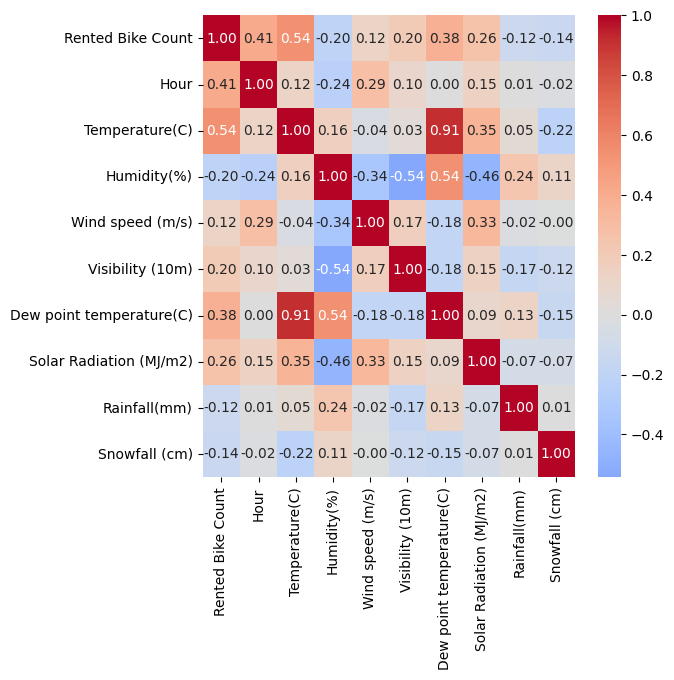

In [5]:
num_df = df.select_dtypes(include=['number'])
plt.figure(figsize=(6, 6))
sns.heatmap(num_df.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)

Разделим выводы на часть, касаемо целевой переменной, и касаемо корреляций между признаками.  
1. Для Rented Bike Count можно выделить по важности следующие признаки(>|0.25|):  
    - Temperature(0.56) - при слишком высокой или достаточно низкой температуре кол-во аренд будет снижаться;
    - Hour(0.43) - очевидное влияние, так как от времени дня зависит занятость, а так же жизненный цикл людей;
    - Dew point temperature(0.4) - удивительная находка, углубимся в вопрос позже;
    - Solar Radiation(0.27) - как и предыдущий признак, меня удивила данная корреляция.
2. Среди признаков имеются линейные зависимости, наиболее значимые из них:
    - Temperature и Dew point temperature - 0.91 - та самая находка оказалась обьясниным физическим явлением(опираясь на источники), признаки являются синонимами, а второе вытекает из первого. Можно сделать вывод что влияние Dew point temperature является ложным и основано лишь на взаимосвязи с параметром temperature
    - Temperature и Solar Radiation - 0.35 - так же описывается физической зависимостью, показатель солнечной радиации не влияет на ключевую переменную. То же касается и остальных корреляций между признаками, которые уже не имеют линейного влияния на кол-во аренд, обоснованные физические процессы, которые в реальной жизни не имеют действительного влияния на признак. 





(array([1.000000e+00, 1.000000e+00, 2.000000e+00, 3.000000e+00,
        2.700000e+01, 5.600000e+01, 1.430000e+02, 4.110000e+02,
        9.960000e+02, 2.408000e+03, 5.134000e+03, 1.118400e+04,
        2.328600e+04, 4.580400e+04, 8.663500e+04, 1.554540e+05,
        2.692540e+05, 4.471090e+05, 7.129120e+05, 1.084694e+06,
        1.587019e+06, 2.229933e+06, 3.008556e+06, 3.896832e+06,
        4.845868e+06, 5.799838e+06, 6.658173e+06, 7.354022e+06,
        7.806881e+06, 7.956430e+06, 7.801436e+06, 7.350141e+06,
        6.656852e+06, 5.796882e+06, 4.847473e+06, 3.895224e+06,
        3.004409e+06, 2.227910e+06, 1.585230e+06, 1.084653e+06,
        7.116420e+05, 4.472770e+05, 2.697880e+05, 1.560060e+05,
        8.650800e+04, 4.589300e+04, 2.326000e+04, 1.130100e+04,
        5.254000e+03, 2.242000e+03, 9.510000e+02, 3.740000e+02,
        1.390000e+02, 5.500000e+01, 1.900000e+01, 9.000000e+00,
        6.000000e+00]),
 array([21., 22., 23., 24., 25., 26., 27., 28., 29., 30., 31., 32., 33.,
       

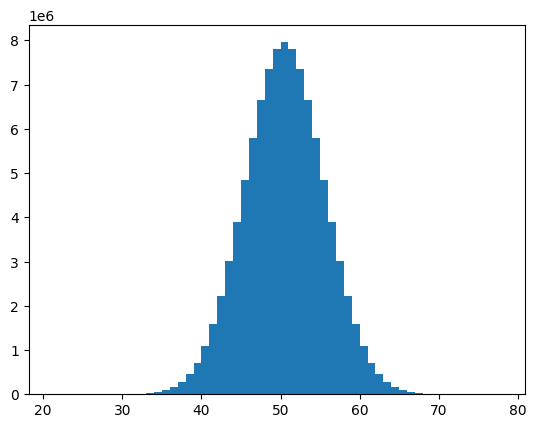

In [17]:
bi = np.random.binomial(100, 0.5, 100000000)
plt.hist(bi, bins='auto')